## Comparaison statistique de normalisation LiDAR selon le MNT

Ce script permet de comparer quantitativement la normalisation de nuages de points pour les deux MNT possibles (**WMS IGN** vs **IDW**).

In [1]:
!pip install laspy[lazrs] numpy pandas tabulate

In [4]:
import laspy
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.spatial import cKDTree
import rasterio
from rasterio.transform import from_origin

def comparaison_ign_idw(chemin_ign, chemin_idw, rayon_max=0.5, resolution=0.5, classes_filtre=[3, 4, 5]):
    """
    Comparaison IGN vs IDW-kNN :
    - Filtrage sur les classes spécifiées (par défaut 3, 4, 5)
    - Tableau descriptif (min, max, moyenne, bruit, etc.) avec seuil à 30 cm
    - Appariement spatial KNN + rayon max
    - RMSE, MAE, biais
    - Carte raster des résidus
    """

    # --- 1. Lecture et filtrage des nuages ---
    las_ign = laspy.read(str(chemin_ign))
    las_idw = laspy.read(str(chemin_idw))

    if classes_filtre:
        mask_ign = np.isin(las_ign.classification, classes_filtre)
        las_ign.points = las_ign.points[mask_ign]
        
        mask_idw = np.isin(las_idw.classification, classes_filtre)
        las_idw.points = las_idw.points[mask_idw]

    if len(las_ign.points) == 0 or len(las_idw.points) == 0:
        raise ValueError("Erreur : L'un des nuages de points est vide après le filtrage des classes.")

    # --- 2. Tableau descriptif pour chaque nuage ---
    def stats_nuage(las, nom):
        z = las.z
        total = len(z)
        return {
            "Méthode": nom,
            "Z min (m)": round(np.min(z), 3),
            "Z max (m)": round(np.max(z), 3),
            "Z moyen (m)": round(np.mean(z), 3),
            "Écart-type (m)": round(np.std(z), 3),
            "% Z < 0": round(np.sum(z < 0) / total * 100, 2),
            "% 0–30 cm": round(np.sum((z >= 0) & (z <= 0.30)) / total * 100, 2),
            "% > 30 cm": round(np.sum(z > 0.30) / total * 100, 2),
            "Nb points": total
        }

    df_descriptif = pd.DataFrame([
        stats_nuage(las_ign, "IGN"),
        stats_nuage(las_idw, "IDW-kNN")
    ])

    # --- 3. Appariement spatial ---
    coords_ign = np.vstack((las_ign.x, las_ign.y)).T
    coords_idw = np.vstack((las_idw.x, las_idw.y)).T

    z_ign = las_ign.z
    z_idw = las_idw.z

    tree = cKDTree(coords_idw)
    dist, idx = tree.query(coords_ign, k=1)

    mask = dist < rayon_max
    print(f"Points appariés : {np.sum(mask)} / {len(coords_ign)}")

    z_ign_m = z_ign[mask]
    z_idw_m = z_idw[idx[mask]]

    residus = z_ign_m - z_idw_m

    # --- 4. Statistiques comparatives ---
    rmse = np.sqrt(np.mean(residus**2))
    mae = np.mean(np.abs(residus))
    biais = np.mean(residus)

    df_comparaison = pd.DataFrame({
        "RMSE (m)": [round(rmse, 3)],
        "MAE (m)": [round(mae, 3)],
        "Biais IGN - IDW (m)": [round(biais, 3)],
        "Nb points comparés": [np.sum(mask)]
    })

    # --- 5. Carte raster des résidus ---
    xmin, xmax = np.min(coords_ign[:,0]), np.max(coords_ign[:,0])
    ymin, ymax = np.min(coords_ign[:,1]), np.max(coords_ign[:,1])

    cols = int(np.ceil((xmax - xmin) / resolution))
    rows = int(np.ceil((ymax - ymin) / resolution))

    raster = np.full((rows, cols), np.nan, dtype=np.float32)

    col = ((coords_ign[mask,0] - xmin) / resolution).astype(int)
    row = ((ymax - coords_ign[mask,1]) / resolution).astype(int)

    # Empêche les dépassements
    col = np.clip(col, 0, cols - 1)
    row = np.clip(row, 0, rows - 1)

    raster[row, col] = residus

    chemin_raster = chemin_ign.parent / "residus_IGN_moins_IDW.tif"

    with rasterio.open(
        chemin_raster, "w", driver="GTiff",
        height=rows, width=cols, count=1,
        dtype=np.float32, crs="EPSG:2154",
        transform=from_origin(xmin, ymax, resolution, resolution),
        nodata=np.nan
    ) as dst:
        dst.write(raster, 1)

    return df_descriptif, df_comparaison, chemin_raster
    
dossier = Path(r"C:\Users\tliegeon\Downloads\controle_mnt")

f_ign = dossier / "norma_IGN.laz"
f_idw = dossier / "norma_IDW.laz"

tb_desc, tb_comp, carte = comparaison_ign_idw(f_ign, f_idw)

print("\n=== Tableau descriptif ===")
print(tb_desc)

print("\n=== Tableau comparatif IGN vs IDW ===")
print(tb_comp)

print("\nCarte des résidus :", carte)

Points appariés : 3072319 / 3072325

=== Tableau descriptif ===
   Méthode  Z min (m)  Z max (m)  Z moyen (m)  Écart-type (m)  % Z < 0  \
0      IGN      -0.99      32.65        1.955           3.717     0.05   
1  IDW-kNN      -0.65      32.65        1.964           3.718     0.03   

   % 0–30 cm  % > 30 cm  Nb points  
0      18.29      81.65    3072325  
1      18.23      81.74    3072318  

=== Tableau comparatif IGN vs IDW ===
   RMSE (m)  MAE (m)  Biais IGN - IDW (m)  Nb points comparés
0     0.079    0.025               -0.009             3072319

Carte des résidus : C:\Users\tliegeon\Downloads\controle_mnt\residus_IGN_moins_IDW.tif


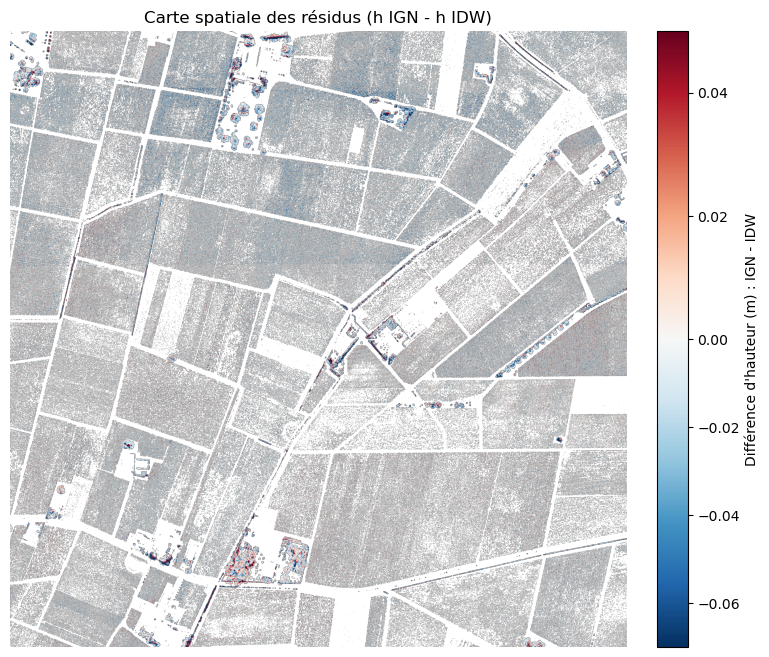

Carte exportée avec succès : C:\Users\tliegeon\Downloads\controle_mnt\residus_IGN_moins_IDW.png


In [5]:
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

chemin_raster = Path(r"C:\Users\tliegeon\Downloads\controle_mnt\residus_IGN_moins_IDW.tif")

def visualiser_carte_residus(chemin_raster):
    """
    Génère et sauvegarde une carte visuelle à partir du raster de résidus.
    """
    # Lecture des données raster
    with rasterio.open(chemin_raster) as src:
        residus = src.read(1)
        nodata = src.nodata

    # Masquage des valeurs NoData
    if nodata is None or np.isnan(nodata):
        residus_masque = np.ma.masked_invalid(residus)
    else:
        residus_masque = np.ma.masked_equal(residus, nodata)

    # Création de la figure
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Définition des bornes de couleurs en excluant les 2% d'extrêmes pour une meilleure lisibilité
    vmin, vmax = np.nanpercentile(residus_masque.filled(np.nan), [2, 98])
    
    # Sécurisation des bornes pour garantir le centrage sur 0
    vmin = min(vmin, -0.01)
    vmax = max(vmax, 0.01)
    norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

    # Affichage de l'image (RdBu_r : Bleu pour le négatif, Blanc pour 0, Rouge pour le positif)
    im = ax.imshow(residus_masque, cmap='RdBu_r', norm=norm)
    
    # Ajout de la barre d'échelle
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Différence d'hauteur (m) : IGN - IDW")
    
    ax.set_title("Carte spatiale des résidus (h IGN - h IDW)")
    ax.axis('off')

    # Sauvegarde au format PNG
    chemin_png = Path(chemin_raster).with_suffix('.png')
    plt.savefig(chemin_png, dpi=300, bbox_inches='tight', transparent=False)
    plt.show()

    print(f"Carte exportée avec succès : {chemin_png}")

# Exécution avec le chemin retourné par la fonction comparaison_ign_idw
visualiser_carte_residus(chemin_raster)